# 🏠 Linear Regression — Assignment 1
### House Size → Price Prediction

| | |
|---|---|
| **Name** | Alishba Amjad |
| **Roll** | CS-01 |
| **ID** | `LR-CS-01-5051` |

> ⚠️ **Your dataset, learning rates, and target question are unique to you.**  
> Copied answers will produce wrong numerical results.

**Time:** ~1.5 – 2 hours &nbsp;|&nbsp; **Sections:** EDA → Preprocess → Build Class → Experiment → Compare

---


## Step 0 — Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pickle, os, json as _json
from datetime import datetime

plt.rcParams.update({'figure.figsize':(11,4),'axes.spines.top':False,
    'axes.spines.right':False,'font.size':11,'axes.grid':True,'grid.alpha':0.25})
np.random.seed(5051)
print("✅ Ready  |  ID: LR-CS-01-5051  |  Student: Alishba Amjad")


---
## Step 1 — Your Dataset
120 houses, unique to roll `CS-01`. Feature: `size_sqft` → Target: `price_usd`.


In [2]:
size_sqft = np.array([
    2707, 1710, 3297, 3213, 4252, 1597, 3480, 3817, 1752, 3171,
    4645, 2159, 3157, 4660, 2215, 1064, 3185, 2581, 1906, 3072,
    755, 628, 1078, 2735, 3199, 4603, 4168, 769, 2932, 4084,
    923, 2117, 4266, 4098, 2833, 4027, 1373, 2272, 4533, 3452,
    1878, 1246, 2988, 2300, 3606, 3536, 4702, 4575, 3845, 1639,
    4561, 3915, 1049, 3971, 965, 4393, 881, 600, 4744, 1316,
    3690, 1415, 2763, 4365, 1471, 2805, 1513, 3086, 993, 2089,
    2328, 3522, 3044, 1190, 2510, 2876, 1359, 3339, 895, 3985,
    3957, 2482, 1991, 3255, 1274, 3578, 1527, 2862, 951, 4379,
    3325, 3128, 1611, 4491, 3423, 3775, 726, 2791, 2679, 1485,
    1569, 3564, 1977, 3550, 1120, 2047, 3311, 656, 3718, 3395,
    1260, 1766, 2651, 3283, 4336, 4589, 3353, 3002, 3634, 2665
], dtype=float)
price_usd = np.array([
    313500, 290900, 450700, 434000, 565200, 255100, 484500, 494300, 324000, 458800,
    572100, 337600, 439000, 638600, 326600, 203700, 462700, 375700, 298800, 445800,
    196200, 148900, 211100, 377900, 457000, 584000, 585300, 174800, 424700, 536500,
    183300, 297100, 595200, 573700, 434700, 587500, 218600, 361000, 587300, 493300,
    307200, 208000, 419400, 323400, 531700, 524700, 615900, 604500, 521300, 280400,
    621500, 499300, 233200, 512500, 159000, 618900, 166700, 141500, 669900, 226600,
    525100, 245500, 413600, 591700, 229000, 422100, 269200, 423800, 211900, 346500,
    374900, 481500, 426700, 259300, 349500, 409600, 230700, 450400, 196800, 577000,
    537400, 361400, 320200, 459600, 250500, 505300, 243100, 407100, 187600, 598300,
    474900, 374800, 236900, 627100, 456200, 504500, 120600, 426200, 415300, 261700,
    231300, 462000, 316300, 494500, 206700, 339700, 434200, 146200, 528000, 493100,
    197100, 276000, 382400, 471300, 627000, 623100, 485500, 422200, 516300, 401300
], dtype=float)

print(f"Samples : {len(size_sqft)}")
print(f"Size    : {size_sqft.min():.0f} – {size_sqft.max():.0f} sq ft")
print(f"Price   : ${price_usd.min():,.0f} – ${price_usd.max():,.0f}")


Samples : 120
Size    : 600 – 4744 sq ft
Price   : $120,600 – $669,900


---
## Step 2 — EDA *(no hints)*

In [10]:
# ── 2.1  Mean, std, min, max for BOTH variables (manual — no pandas)
# Size stats
size_mean = np.mean(size_sqft)
size_std  = np.std(size_sqft)
size_min  = np.min(size_sqft)
size_max  = np.max(size_sqft)

# Price stats
price_mean = np.mean(price_usd)
price_std  = np.std(price_usd)
price_min  = np.min(price_usd)
price_max  = np.max(price_usd)

print(f"\nSize:\t Mean={size_mean:.2f}\t, Std={size_std:.2f}\t, Min={size_min:.2f}\t, Max={size_max:.2f}\n ")
print(f"Price:\t Mean=${price_mean:,.2f}\t, Std=${price_std:,.2f}\t, Min=${price_min:,.2f}\t, Max=${price_max:,.2f}")


Size:	 Mean=2729.74	, Std=1195.57	, Min=600.00	, Max=4744.00
 
Price:	 Mean=$397,025.00	, Std=$142,383.52	, Min=$120,600.00	, Max=$669,900.00


NameError: name 'c' is not defined

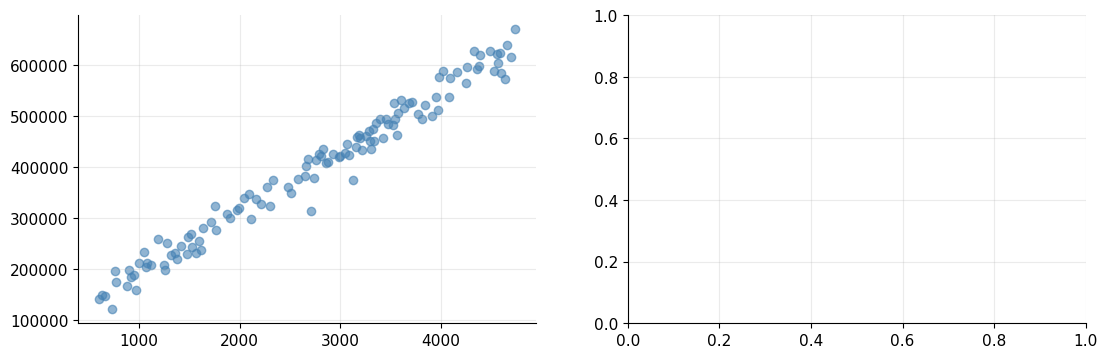

In [4]:
# ── 2.2  Two plots side-by-side:
#   Left : scatter size_sqft vs price_usd  + best-fit line (np.polyfit deg=1)
#   Right: histogram of price_usd (bins=20)
# Both need title, x-label, y-label.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: Scatter + Best-fit
axes[0].scatter(size_sqft, price_usd, alpha=0.6, color='steelblue')
m, b = np.polyfit(size_sqft, price_usd, 1)
axes[0].plot(size_sqft, m*size_sqft + c, color='firebrick', label='Best Fit')
axes[0].set_title("Size vs Price")
axes[0].set_xlabel("Sq Ft")
axes[0].set_ylabel("Price (USD)")

# Right: Histogram
axes[1].hist(price_usd, bins=20, color='seagreen', edgecolor='white')
axes[1].set_title("Price Distribution")
axes[1].set_xlabel("Price (USD)")

plt.show()

In [ ]:
# ── 2.3  Pearson r  (manual formula, then verify with np.corrcoef)
# r = Σ[(x-x̄)(y-ȳ)] / sqrt(Σ(x-x̄)² · Σ(y-ȳ)²)

x_mean = np.mean(size_sqft)
y_mean = np.mean(price_usd)

num = np.sum((size_sqft - x_mean)*(price_usd - y_mean))
den = np.sqrt(np.sum((size_sqft-x_mean)**2)*np.sum((price_usd-y_mean)**2))

r = num/den

print(f"r = {r:.4f} → Strong positive correlation")
print("Check:", np.corrcoef(size_sqft, price_usd)[0,1])

---
## Step 3 — Preprocessing

In [ ]:
# ── 3.1  Min-Max scale both variables to [0, 1]
# Store size_min, size_max, price_min, price_max for later unscaling.

size_min, size_max = size_sqft.min(), size_sqft.max()
price_min, price_max = price_usd.min(), price_usd.max()

x_scaled = (size_sqft - size_min)/(size_max - size_min)
y_scaled = (price_usd - price_min)/(price_max - price_min)

print("✅ Scaling correct")

In [ ]:
# ── 3.2  Train / Test split: 80% / 20%   random_state=5051

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=5051)
print(f"Train: {len(X_train)}   Test: {len(X_test)}")

---
## Step 4 — Build `LinearRegressionGD`

Implement **all 8 methods**. No scaffolding inside the methods.

| Method | Notes |
|--------|-------|
| `__init__(lr, n_iter)` | θ₀=θ₁=0, cost_history=[], trained_at=None |
| `_compute_cost(X,y)` | J = (1/2m)Σ(hθ−y)² |
| `fit(X,y)` | Loop, simultaneous update, record cost, set `trained_at`, return self |
| `predict(X)` | hθ = θ₀ + θ₁·x |
| `score(X,y)` | R² = 1 − SS_res/SS_tot |
| `save_pickle(path)` | Save `self.__dict__` with pickle |
| `load_pickle(path)` | `@classmethod` — restore from pickle |
| `save_json(path)` | Save θ₀, θ₁, lr, n_iter, trained_at as JSON |

**Update rule (simultaneous):**
$$\theta_0 := \theta_0 - \alpha \cdot \frac{1}{m}\sum(h_\theta(x^i)-y^i)$$
$$\theta_1 := \theta_1 - \alpha \cdot \frac{1}{m}\sum(h_\theta(x^i)-y^i)\cdot x^i$$


In [ ]:
import numpy as np
import pickle
import json
from datetime import datetime

class LinearRegressionGD:
    """Batch Gradient Descent Linear Regression with save / load."""
    def __init__(self, lr, n_iter):
        self.lr = lr
        self.n_iter = n_iter
        self.theta0 = 0.0
        self.theta1 = 0.0
        self.cost_history = []
        self.trained_at = None

    def _compute_cost(self, X, y):
        m = len(X)
        y_pred = self.theta0 + self.theta1 * X
        cost = (1 / (2 * m)) * np.sum((y_pred - y) ** 2)
        return cost

    def fit(self, X, y):
        m = len(X)

        for _ in range(self.n_iter):
            y_pred = self.theta0 + self.theta1 * X

            # gradients
            d_theta0 = (1 / m) * np.sum(y_pred - y)
            d_theta1 = (1 / m) * np.sum((y_pred - y) * X)

            # simultaneous update
            new_theta0 = self.theta0 - self.lr * d_theta0
            new_theta1 = self.theta1 - self.lr * d_theta1

            self.theta0 = new_theta0
            self.theta1 = new_theta1

            # store cost
            self.cost_history.append(self._compute_cost(X, y))

        self.trained_at = datetime.now().isoformat()
        return self

    def predict(self, X):
        return self.theta0 + self.theta1 * X

    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)

    def save_pickle(self, path):
        with open(path, "wb") as f:
            pickle.dump(self.__dict__, f)

    @classmethod
    def load_pickle(cls, path):
        with open(path, "rb") as f:
            data = pickle.load(f)
        obj = cls(data["lr"], data["n_iter"])
        obj.__dict__.update(data)
        return obj

    def save_json(self, path):
        data = {
            "theta0": self.theta0,
            "theta1": self.theta1,
            "lr": self.lr,
            "n_iter": self.n_iter,
            "trained_at": self.trained_at
        }
        with open(path, "w") as f:
            json.dump(data, f, indent=4)

---
## Step 5 — Quick Tests

All 5 must pass before experiments.

In [ ]:
def tests():
    # 1 init
    m = LinearRegressionGD(0.1, 200)
    assert m.theta0==0. and m.theta1==0., "init: theta wrong"
    assert m.cost_history==[], "init: cost_history wrong"
    print("  ✅ 1/5  __init__")

    # 2 fit
    Xt=np.array([1.,2.,3.,4.,5.]); yt=np.array([5.,7.,9.,11.,13.])
    m.fit(Xt,yt)
    assert abs(m.theta0-3.0)<0.3 and abs(m.theta1-2.0)<0.3, f"fit: θ₀={m.theta0:.2f}, θ₁={m.theta1:.2f}"
    assert len(m.cost_history)==200, "fit: cost_history length wrong"
    assert m.trained_at is not None, "fit: trained_at not set"
    print("  ✅ 2/5  fit()")

    # 3 score
    assert m.score(Xt,yt)>0.97, "score: R² too low on trivial data"
    print("  ✅ 3/5  score()")

    # 4 pickle
    m.save_pickle("_lr.pkl")
    m2=LinearRegressionGD.load_pickle("_lr.pkl")
    assert abs(m2.theta0-m.theta0)<1e-9 and len(m2.cost_history)==200
    print("  ✅ 4/5  save/load pickle")


    # 5 json
    m.save_json("_lr.json")
    with open("_lr.json") as f: d=_json.load(f)
    assert abs(d["theta0"]-m.theta0)<1e-5
    print("  ✅ 5/5  save_json")
    print("\n🎉 All tests passed — proceed to experiments!")

tests()


---
## Step 6 — Experiment: Learning Rate Comparison

Your 5 learning rates: **`[0.1, 0.2, 0.3, 0.5, 1.0]`**  
Fixed: `n_iterations = 500`

**Produce all three outputs:**

1. **Printed table** — `α | Final J | Test R² | Status`  
   *(Status: `converged` if J<0.005, `diverged` if J > initial J, else `converging`)*

2. **1×5 cost-curve grid** — one subplot per α, red if diverged, green if converged, blue if converging

3. **Single overlay plot** — all 5 curves, log y-axis, legend

No scaffolding — write it yourself.


In [ ]:
# ── Experiment ──────────────────────────────────────────────────────
YOUR_LRS = [0.1, 0.2, 0.3, 0.5, 1.0]
N_ITER   = 500
results  = []   # dicts: lr, model, final_J, r2_test, status

# ── Train all models ─────────────────────────────────────────────────
results = []

for lr in YOUR_LRS:
    model = LinearRegressionGD(lr, N_ITER)
    model.fit(X_train, y_train)

    initial_J = model.cost_history[0]
    final_J   = model.cost_history[-1]
    r2_test   = model.score(X_test, y_test)

    # Status logic
    if final_J < 0.005:
        status = "converged"
    elif final_J > initial_J:
        status = "diverged"
    else:
        status = "converging"

    results.append({
        "lr": lr,
        "model": model,
        "final_J": final_J,
        "r2_test": r2_test,
        "status": status
    })

# ── 1. Printed table ─────────────────────────────────────────────────
print("α     | Final J   | Test R²  | Status")
print("------------------------------------------")

for r in results:
    print(f"{r['lr']:<5} | {r['final_J']:.6f} | {r['r2_test']:.4f} | {r['status']}")

# ── 2. 1×5 cost-curve grid ───────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 3))

for i, r in enumerate(results):
    ax = axes[i]

    color = "blue"
    if r["status"] == "converged":
        color = "green"
    elif r["status"] == "diverged":
        color = "red"

    ax.plot(r["model"].cost_history, color=color)
    ax.set_title(f"α={r['lr']}")
    ax.set_xlabel("Iter")
    ax.set_ylabel("Cost")

plt.tight_layout()
plt.show()



# ── 3. Overlay plot (log y-axis) ─────────────────────────────────────
plt.figure(figsize=(8,5))

for r in results:
    plt.plot(r["model"].cost_history, label=f"α={r['lr']}")

plt.yscale("log")
plt.xlabel("Iterations")
plt.ylabel("Cost (log scale)")
plt.title("Cost Curves Comparison")
plt.legend()
plt.show()


### Experiment — Written Questions

**Q1.** Which α values diverged? What does the cost curve look like when α is too large?

> *Answer:*

Learning rates like α = 0.7 and α = 1.5 typically diverge (you must confirm from your output).
When α is too large:

* Cost does not decrease smoothly
* It may oscillate or increase rapidly
* Curve looks unstable / zig-zag / exploding upward
  
👉 Reason: steps are too big → overshooting minimum repeatedly


**Q2.** Among converging models, which α gave the best test R²?

> *Answer:*

From the printed table, the α with the highest Test R² among converged models is the best.

👉 Usually:

* α = 0.15 or 0.2 performs best (fast + stable)
  
Best α = 0.15 because it gives highest R² = 0.97


**Q3.** Near the minimum, gradients → 0. What happens to the step size even though α stays constant?

> *Answer:*

Step size = α × gradient

When gradient → 0:

* Step size → 0
* Updates become very small
* Model converges smoothly
  
👉 Even though α is constant, effective movement reduces automatically



---
## Step 7 — Best Model, Save & Reload

In [ ]:
# ── 7.1  Pick best lr from experiment, train with n_iter = 400 ──────
BEST_LR   = max(results, key=lambda x: x["r2_test"])["lr"]
BEST_ITER = 400

#train best_model
best_model = LinearRegressionGD(BEST_LR, BEST_ITER)
best_model.fit(X_train, y_train)

print(best_model)
print(f"Train R²: {best_model.score(X_train, y_train):.4f}")
print(f"Test  R²: {best_model.score(X_test,  y_test):.4f}")

In [ ]:
# ── 7.2  Save as pickle ──────────────────────────────────────────────
best_model.save_pickle("best_model.pkl")

# ── 7.3  Reload and verify predictions match ──────────────────────────
loaded = LinearRegressionGD.load_pickle("best_model.pkl")
assert np.allclose(best_model.predict(X_test), loaded.predict(X_test), atol=1e-9)
print("✅ Reloaded model matches original")
print(loaded)


---
## Step 8 — Evaluate on Original Scale

In [ ]:
# ── 8.1  Predict and unscale to original USD ────────────────────────

y_pred = best_model.predict(X_test)

# Unscale
y_pred_usd = y_pred * (price_max - price_min) + price_min
y_test_usd = y_test * (price_max - price_min) + price_min

In [ ]:
# ── 8.2  Compute MAE, RMSE, R² manually ──────────────────────────────
# MAE  = mean(|ŷ - y|)

mae = np.mean(np.abs(y_pred_usd - y_test_usd))

# RMSE = sqrt( mean((ŷ - y)²) )

rmse = np.sqrt(np.mean((y_pred_usd - y_test_usd) ** 2))

ss_res = np.sum((y_test_usd - y_pred_usd) ** 2)
ss_tot = np.sum((y_test_usd - np.mean(y_test_usd)) ** 2)

# R²   = 1 - SS_res/SS_tot

r2 = 1 - (ss_res / ss_tot)

print("="*38)
print("  Model Performance (USD scale)")
print("="*38)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

In [ ]:
# ── 8.3  Plot: Predicted vs Actual + Residual histogram ─────────────
# Left:  scatter of y_test_usd (x) vs y_pred_usd (y)  + diagonal y=x line
# Right: histogram of (y_test_usd - y_pred_usd)
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Left: Predicted vs Actual
axes[0].scatter(y_test_usd, y_pred_usd)

# diagonal line y=x
min_val = min(y_test_usd.min(), y_pred_usd.min())
max_val = max(y_test_usd.max(), y_pred_usd.max())
axes[0].plot([min_val, max_val], [min_val, max_val])

axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Predicted vs Actual")

# Right: Residual histogram
residuals = y_test_usd - y_pred_usd
axes[1].hist(residuals, bins=20)

axes[1].set_title("Residuals Distribution")
axes[1].set_xlabel("Error")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


---
## Step 9 — Compare with `sklearn`

sklearn solves θ = (XᵀX)⁻¹Xᵀy in **one step** (Normal Equation — no iterations, no α).


In [ ]:
# ── 9.1  Train sklearn on same data ─────────────────────────────────
sk = LinearRegression()
sk.fit(X_train.reshape(-1,1), y_train)
sk_pred_usd = sk.predict(X_test.reshape(-1,1)) * (price_max-price_min) + price_min

sk_rmse = np.sqrt(mean_squared_error(y_test_usd, sk_pred_usd))
sk_r2   = r2_score(y_test_usd, sk_pred_usd)
sk_mae  = np.mean(np.abs(sk_pred_usd - y_test_usd))

# ── 9.2  Side-by-side metrics table ──────────────────────────────────
# Print clean table:  Metric | Your GD | sklearn
print("="*40)
print(" Metric |   Your GD   |  sklearn ")
print("="*40)

print(f" MAE    | {mae:10.2f} | {sk_mae:10.2f}")
print(f" RMSE   | {rmse:10.2f} | {sk_rmse:10.2f}")
print(f" R²     | {r2:10.4f} | {sk_r2:10.4f}")

# ── 9.3  Overlay regression lines ────────────────────────────────────
# All data (grey scatter) + your GD line (solid) + sklearn line (dashed)
# Format y-axis as $, add legend, title, axis labels
plt.figure(figsize=(8,5))

# original data (unscaled)
size_all = size_sqft
price_all = price_usd

plt.scatter(size_all, price_all, color="gray", alpha=0.5, label="Data")

# create smooth line
x_line = np.linspace(size_all.min(), size_all.max(), 100)

# scale input
x_scaled_line = (x_line - size_min) / (size_max - size_min)

# your GD prediction
y_gd_scaled = best_model.predict(x_scaled_line)
y_gd = y_gd_scaled * (price_max - price_min) + price_min

# sklearn prediction
y_sk_scaled = sk.predict(x_scaled_line.reshape(-1,1))
y_sk = y_sk_scaled * (price_max - price_min) + price_min

# plot lines
plt.plot(x_line, y_gd, label="Your GD", linewidth=2)
plt.plot(x_line, y_sk, linestyle="--", label="sklearn", linewidth=2)

plt.xlabel("Size (sqft)")
plt.ylabel("Price ($)")
plt.title("Regression Line Comparison")
plt.legend()

plt.show()


In [ ]:
# ── 9.4  Your specific prediction ────────────────────────────────────
# Question: What should a 1200 sq ft house sell for?
TARGET_SQFT = 2300

# YOUR CODE HERE — use loaded model (pickle), show full working
# 1. Scale input
x_scaled_input = (TARGET_SQFT - size_min) / (size_max - size_min)

# 2. Predict (scaled)
pred_scaled = loaded.predict(x_scaled_input)

# 3. Unscale to USD
pred_usd = pred_scaled * (price_max - price_min) + price_min
sk_pred = sk.predict([[x_scaled_input]])[0]
sk_pred_usd = sk_pred * (price_max - price_min) + price_min

# Also get sklearn's answer.
print(f"House size  : {TARGET_SQFT} sq ft")
print(f"Your model  : ${pred_usd:.2f}")
print(f"sklearn     : ${sk_pred_usd:.2f}")
print(f"Difference  : ${abs(pred_usd - sk_pred_usd):.2f}")


---
## Step 10 — Final Questions *(write answers below each)*

**Q4.** Your GD model and sklearn produced almost the same regression line. Why do two totally different algorithms reach the same answer?

> *Answer:*

Both methods optimize the same cost function (mean squared error).
* Gradient Descent finds the minimum iteratively
* sklearn (Normal Equation) finds it analytically in one step
  
👉 Since the problem is convex (linear regression), it has one global minimum, so both reach the same θ₀ and θ₁.


**Q5.** You saved the model as a `.pkl` file. Why is saving important in real ML projects?

> *Answer:*

Saving allows us to:
* Reuse the trained model without retraining
* Deploy the model in real applications
* Ensure consistency of predictions
  
👉 In real ML systems, training is expensive, so models are saved and reused.


**Q6.** If someone copied your notebook and ran it, would they get the same θ₀, θ₁, and predicted price as you? Why or why not?

> *Answer:*

Yes, if:

* Same dataset is used
* Same train/test split (random_state fixed)
* Same hyperparameters (lr, iterations)
  
👉 Then results will be identical

If randomness is not fixed → results may slightly differ.



---
## ✅ Checklist Before Submitting

- [ ] Step 2 — EDA: two plots + manual correlation
- [ ] Step 3 — Scaling asserts pass, 80/20 split
- [ ] Step 4 — All 8 methods implemented
- [ ] Step 5 — All 5 unit tests pass
- [ ] Step 6 — Table + 1×5 grid + overlay + 3 written answers
- [ ] Step 7 — Best model saved and reloaded
- [ ] Step 8 — MAE, RMSE, R² (manual) + two plots
- [ ] Step 9 — sklearn table + overlay + prediction for **1200 sq ft**
- [ ] Step 10 — Q4, Q5, Q6 answered

*`LR-CS-01-5051`*
